# Analyzing the I-94 Traffic Dataset to find pattern affecting the traffic

## Introduction

The project mainly covers differnt visualization techniques to analyze the traffic dataset in order to clearly communicate the different factors affecting the traffic. The goal is to analyze various patterns and trends affecting the daily traffic.


### Reading the CSV file

In [1]:
# Importing necessary module.
import pandas as pd

# Reading the CSV file.
traffic = pd.read_csv('../../dataset/Metro_Interstate_Traffic_Volume.csv')

# Examining the first five row.
traffic.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [2]:
# Examining the last five row.
traffic.tail()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
48199,NaN,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543
48200,NaN,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781
48201,NaN,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159
48202,NaN,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450
48203,NaN,282.12,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 23:00:00,954


In [3]:
# Collecting Necessary Information About The Dataset.
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


From the above analsis we have conclude that they are 9 columns. The holiday columns have only 61 none null value of the total 48204 datapoint.

### Plotting Visualization

In [4]:
# Importing matplotlib module for visualization
import matplotlib.pyplot as plt

# To plot graph in jupyter notebook
%matplotlib inline 

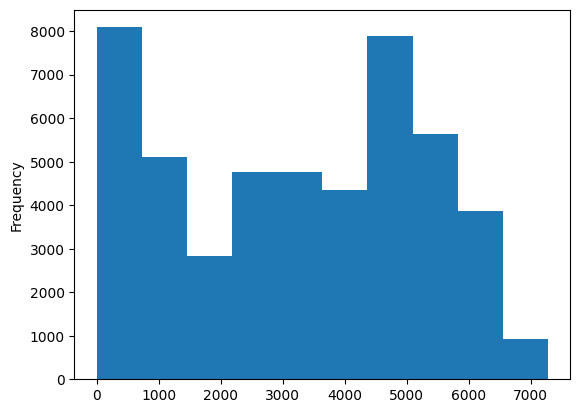

In [5]:
# Histogram to visualize the distribution of traffic_volume
traffic['traffic_volume'].plot.hist()
plt.show()

In [6]:
# Describing the traffic_volumne column
traffic['traffic_volume'].describe()

count    48204.000000
mean      3259.818355
std       1986.860670
min          0.000000
25%       1193.000000
50%       3380.000000
75%       4933.000000
max       7280.000000
Name: traffic_volume, dtype: float64

From the data we can observe that the average number of vechicle in the route is 3259. And the maximum number of vehicel passing throught the road is 7280.

### Day time vs Night time Traffic

In [7]:
# Importing Datetime module
import datetime as dt

# Converting the date_time column to standard pandas datetime column
traffic['date_time'] = pd.to_datetime(traffic['date_time'])
traffic['date_time'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 48204 entries, 0 to 48203
Series name: date_time
Non-Null Count  Dtype         
--------------  -----         
48204 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 376.7 KB


In [8]:
# storing the traffic data from 7 a.m to 7 p.m in day variabe.
day = traffic.copy()[(traffic['date_time'].dt.hour >=7) & (traffic['date_time'].dt.hour < 19)]
           
# storing night time traffic data from 7 p.m to 7 a.m
night = traffic.copy()[(traffic['date_time'].dt.hour >= 19) | (traffic['date_time'].dt.hour < 7)]


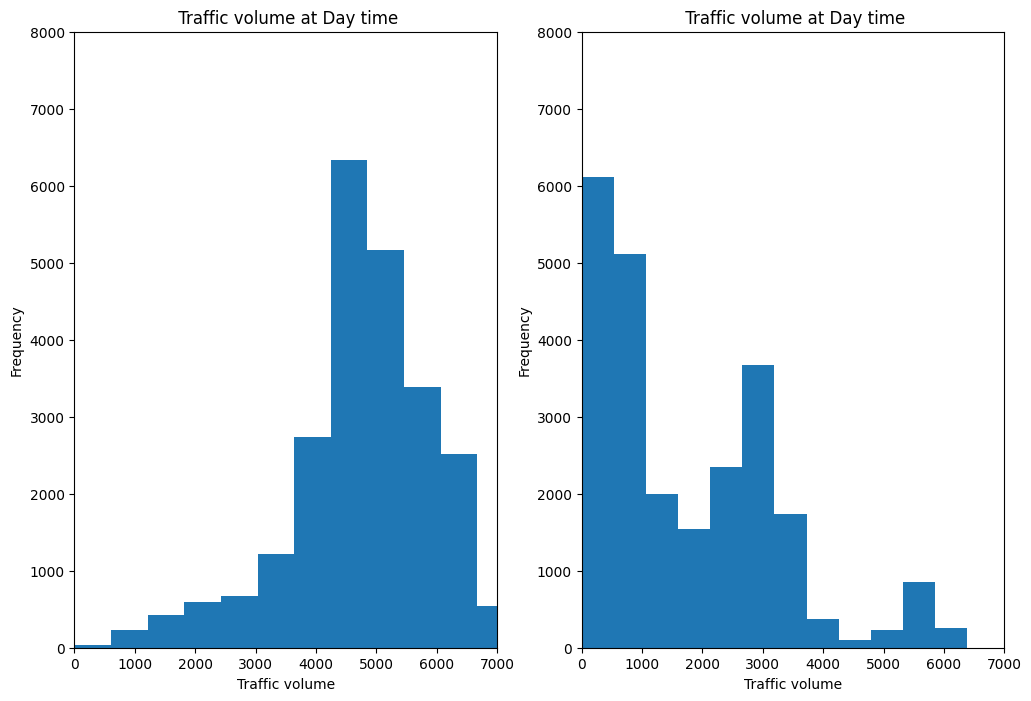

In [9]:
# Plotting the histogram to analyze difference in day and night
plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
day['traffic_volume'].plot.hist(bins = 12)
plt.title(' Traffic volume at Day time')
plt.xlabel('Traffic volume')
plt.ylabel('Frequency')
plt.xlim([0, 7000])
plt.ylim([0, 8000])
plt.subplot(1, 2, 2)
night['traffic_volume'].plot.hist(bins = 12)
plt.title('Traffic volume at night time')
plt.title(' Traffic volume at Day time')
plt.xlabel('Traffic volume')
plt.ylabel('Frequency')
plt.xlim([0, 7000])
plt.ylim([0, 8000])
plt.show()

In [10]:
# Checking the information in day column.
day['traffic_volume'].describe()

count    23877.000000
mean      4762.047452
std       1174.546482
min          0.000000
25%       4252.000000
50%       4820.000000
75%       5559.000000
max       7280.000000
Name: traffic_volume, dtype: float64

In [11]:
night['traffic_volume'].describe()

count    24327.000000
mean      1785.377441
std       1441.951197
min          0.000000
25%        530.000000
50%       1287.000000
75%       2819.000000
max       6386.000000
Name: traffic_volume, dtype: float64

From the histogram we can observe that the mean for night time(right-skewed) traffic is 1785 which is 2.5 time less than day time(left-skewed). So in this data our main focus should be on the daytime data for traffic analyis.

# Time Indicator of Traffic

In this section, we will analyze day traffic volumne in differnt time parameter such as month, day, hour.

### Monthly traffic volume

In [16]:
# We will create a new column month and groupby it.
day['month'] = day['date_time'].dt.month
by_month = day.groupby('month').mean(numeric_only = True)
by_month['traffic_volume']

month
1     4495.613727
2     4711.198394
3     4889.409560
4     4906.894305
5     4911.121609
6     4898.019566
7     4595.035744
8     4928.302035
9     4870.783145
10    4921.234922
11    4704.094319
12    4374.834566
Name: traffic_volume, dtype: float64

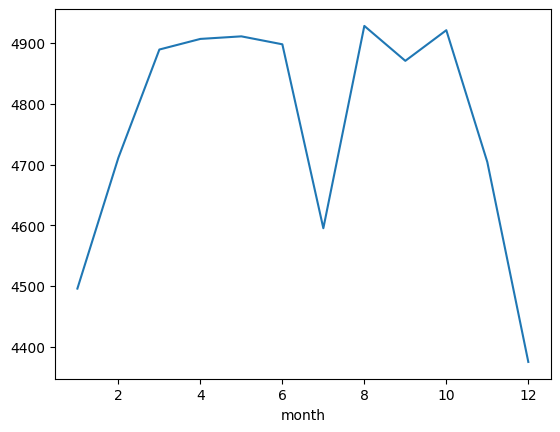

In [20]:
by_month['traffic_volume'].plot.line()
plt.show()

From the line plot, we can observe that, the traffic volume fell by 10% on average in july but recover to and average 5000 per hour in  month. Then in December-February it again fell 15% which indicate the effect of winter in traffic volume in day time.

### Daily Traffic Volume

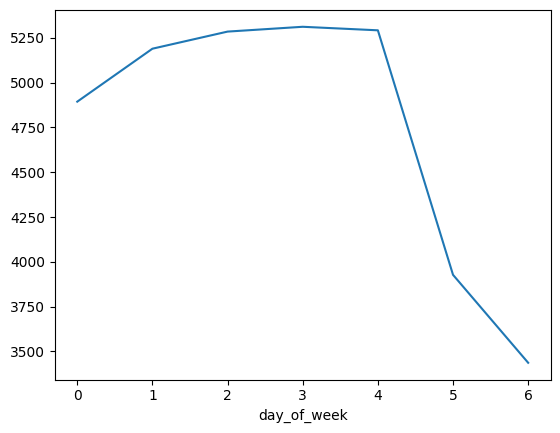

In [22]:
day['day_of_week'] = day['date_time'].dt.dayofweek
by_day = day.groupby('day_of_week').mean(numeric_only = True)
by_day['traffic_volume'].plot.line()
plt.show()

We can observe that the day volume fell by 30 % during weekends compared to weekday which shows an averge traffic of 5000.

### Hourly Traffic Volume
In this section we will analyze the traffic volume of weekends and business day in different chart.

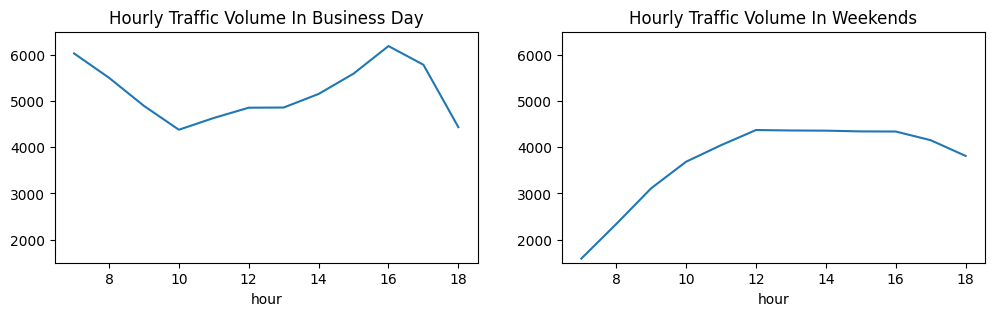

In [34]:
day['hour'] = day['date_time'].dt.hour
business_day = day.copy()[day['day_of_week'] <= 4]
weekends = day.copy()[day['day_of_week'] >= 5]
by_hour_business = business_day.groupby('hour').mean(numeric_only = True)
by_hour_weekends = weekends.groupby('hour').mean(numeric_only = True)

plt.figure(figsize = (12, 3))
plt.subplot(1,2,1)
by_hour_business['traffic_volume'].plot.line()
plt.title('Hourly Traffic Volume In Business Day')
plt.ylim([1500, 6500])

plt.subplot(1,2,2)
by_hour_weekends['traffic_volume'].plot.line()
plt.title('Hourly Traffic Volume In Weekends')
plt.ylim([1500, 6500])

plt.show()

From the first line plot, we can see that in business day the traffic peak between 7 a.m to 9 a.m and 3.pm to 5.pm.

And the second graph shows stready traffic movement from 10 a.m to 6 p.m averaging about 4500.the graph peaked from 1500 to 4500 from 7 a.m to 9 a.m

## Weather Indicator

In [41]:
day.corr(numeric_only = True)['traffic_volume']

temp              0.128317
rain_1h           0.003697
snow_1h           0.001265
clouds_all       -0.032932
traffic_volume    1.000000
month            -0.022337
day_of_week      -0.416453
hour              0.172704
Name: traffic_volume, dtype: float64

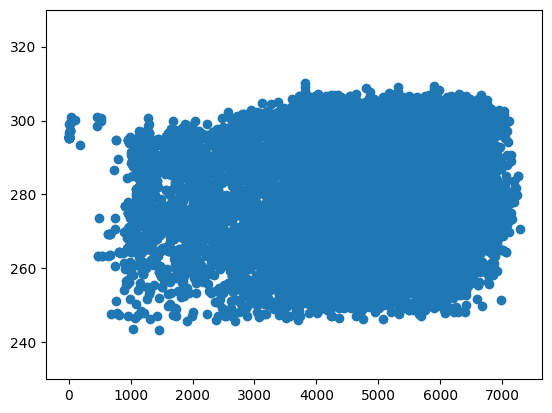

In [44]:
plt.scatter(day['traffic_volume'], day['temp'])
plt.ylim([230, 330])
plt.show()

From the correlation analysis, we can see the temperature have the hightest correlation among the other column provide in the data with +0.12 positive correlation.

Although temperature shows a weak positive correlation, we can't reliable say that it is reliable indicator for heavy traffic.

## Weather Type Indicator


<Axes: ylabel='weather_main'>

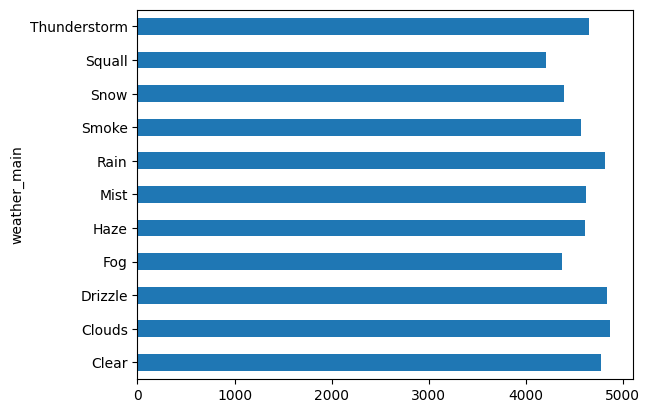

In [57]:
by_weather_main = day.groupby('weather_main').mean(numeric_only = True)
by_weather_main['traffic_volume'].plot.barh()

From the bar plot, we can observe no visible indicaton of weather main affecting the traffic volume

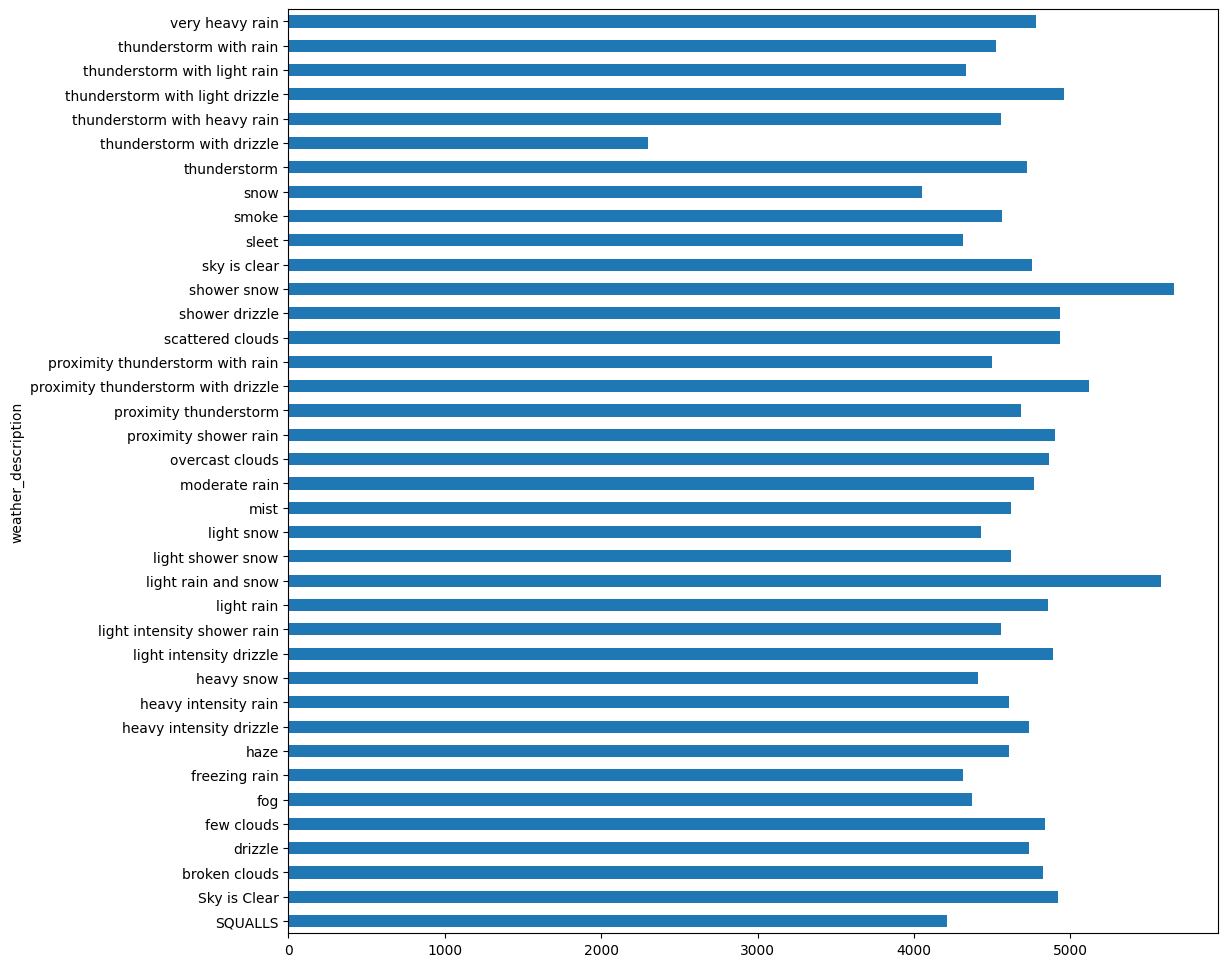

In [60]:
by_weather_description = day.groupby('weather_description').mean(numeric_only=True)
by_weather_description['traffic_volume'].plot.barh(figsize = (12,12))
plt.show()

From the barplot, can you clearly see that 'Thunderstorm with dizzle' severly affect the traffic volumne falling to 2000 per hour.

## Conclusion

We analyze the dataset by differnt metrics like 
a. Time Indicator
We can see the rise in traffic in summer season(march to october) whereas the traffic drops significantly in winter season(novermber to february)
b. Weather Indicator
We can see no reliable factor affectin th